In [45]:
import os
from dotenv import load_dotenv

load_dotenv()

GEMMA_MODEL = os.getenv("GEMMA_MODEL")
BASE_URL = os.getenv("BASE_URL")
EMBEDDING_MODEL = os.getenv("EMBEDDING_MODEL")
API_KEY = os.getenv("API_KEY")
QDRANT_URL = os.getenv("QDRANT_URL")

In [46]:
import re

from bs4 import BeautifulSoup as Soup
from langchain_community.document_loaders.recursive_url_loader import RecursiveUrlLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter

url = "https://python.langchain.com/v0.2/docs/concepts/#langchain-expression-language-lcel"


def extract_main_text(html: str) -> str:
    """토큰을 낭비하는 스크립트·스타일·메뉴 영역을 제거한다."""
    soup = Soup(html, "html.parser")
    for tag in soup(["script", "style", "nav", "footer", "header"]):
        tag.decompose()
    return soup.get_text(" ", strip=True)


# 20단계 재귀 수집은 사이트 대부분을 가져올 수 있으므로 깊이와 문서 수를 제한한다.
loader = RecursiveUrlLoader(url=url, max_depth=2, extractor=extract_main_text)
docs = loader.load()[:30]

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1_200,
    chunk_overlap=120,
    separators=["\n\n", "\n", ". ", " ", ""],
)
doc_chunks = text_splitter.split_documents(docs)

MAX_CONTEXT_CHARS = 6_000
MAX_CONTEXT_CHUNKS = 5


def select_context(question: str) -> str:
    """질문과 단어가 많이 겹치는 소수의 문서 청크만 반환한다."""
    query_terms = {
        term.lower()
        for term in re.findall(r"[A-Za-z0-9_가-힣]+", question)
        if len(term) > 1
    }

    ranked_chunks = []
    for index, document in enumerate(doc_chunks):
        content = document.page_content.strip()
        lowered = content.lower()
        score = sum(lowered.count(term) for term in query_terms)
        ranked_chunks.append((score, -index, content))

    ranked_chunks.sort(reverse=True)
    selected = [item[2] for item in ranked_chunks[:MAX_CONTEXT_CHUNKS]]
    return "\n\n---\n\n".join(selected)[:MAX_CONTEXT_CHARS]


In [47]:
from pydantic import BaseModel, Field
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI

system = """당신은 LCEL(LangChain Expression Language) 전문가인 코딩 어시스턴트입니다.
아래 참고 문서만 이용해 사용자의 질문에 답변하세요.

<reference>
{context}
</reference>

코드는 실행 가능해야 하며 필요한 import와 변수를 포함해야 합니다.
같은 설명이나 코드를 반복하지 말고 간결하게 답변하세요.
"""

code_gen_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("placeholder", "{messages}"),
    ]
)


class CodeSolution(BaseModel):
    prefix: str = Field(description="문제와 접근 방식에 대한 간결한 설명")
    imports: str = Field(description="필요한 import 문")
    code: str = Field(description="import를 제외한 실행 코드")
    description: str = Field(description="코드의 구성과 동작 설명")


llm = ChatOpenAI(
    base_url=BASE_URL,
    api_key=API_KEY,
    model=GEMMA_MODEL,
    temperature=0,
)

code_gen_chain = code_gen_prompt | llm.with_structured_output(CodeSolution)


In [48]:
question = "LCEL로 RAG 체인을 어떻게 만들어?"

solution = code_gen_chain.invoke(
    {
        "context": select_context(question),
        "messages": [("user", question)],
    }
)


In [49]:
print(solution)

prefix='LCEL로 RAG 체인을 만드는 것은 검색 증강 생성(RAG) 애플리케이션을 구축하는 핵심 단계입니다. LangChain Expression Language (LCEL)를 사용하면 검색, 문서 임베딩, LLM 호출 등 모든 구성 요소를 파이프라인처럼 연결하여 강력하고 효율적인 RAG 체인을 만들 수 있습니다.' imports='from langchain.chains import create_stuff_documents_chain\nfrom langchain.chains import create_retrieval_chain\nfrom langchain.schema import Document' code='from langchain_core.runnables import RunnablePassthrough\nfrom langchain_openai import ChatOpenAI\nfrom langchain_core.prompts import ChatPromptTemplate\nfrom langchain_community.vectorstores import Chroma\nfrom langchain_openai import OpenAIEmbeddings\n# 1. 벡터 스토어 및 임베딩 설정 (가정: 이미 데이터베이스에 문서가 존재함)\n# vectorstore = Chroma.as_collection(embedding=OpenAIEmbeddings(), collection_name="my_docs")\n# retriever = vectorstore.as_retriever()\n\n# 2. 프롬프트 템플릿 정의 (LLM에게 질문과 문서를 함께 전달할 틀)\nprompt = ChatPromptTemplate.from_messages([\n    ("system", "다음 문서를 바탕으로 질문에 답하세요: {context}\n{input}"),\n    ("human", "{input}")\n])\n\n# 3. LLM 및 체인 구성 요소 정의\nllm = 

In [50]:
from typing import List, TypedDict


class GraphState(TypedDict, total=False):
    question: str
    error: str
    error_message: str
    messages: List[tuple[str, str]]
    generation: CodeSolution
    iterations: int


In [51]:
MAX_ITERATIONS = 3
MAX_ERROR_CHARS = 1_000


def generate(state: GraphState):
    """원 질문과 가장 최근 오류만 사용해 코드를 생성한다."""
    print("---코드 생성---")
    question = state["question"]
    iterations = state.get("iterations", 0)
    error_message = state.get("error_message", "")

    # 이전 답변 전체를 누적하지 않아 재시도할 때 입력 토큰이 계속 늘지 않는다.
    messages = [("user", question)]
    if error_message:
        messages.append(
            (
                "user",
                "이전 코드의 검사 오류를 수정하세요. 오류: "
                + error_message[:MAX_ERROR_CHARS],
            )
        )

    code_solution = code_gen_chain.invoke(
        {
            "context": select_context(question),
            "messages": messages,
        }
    )
    return {
        "generation": code_solution,
        "messages": messages,
        "iterations": iterations + 1,
        "error_message": "",
    }


def code_check(state: GraphState):
    """생성된 import와 코드의 실행 가능 여부를 검사한다."""
    print("---코드 검사---")
    code_solution = state["generation"]

    try:
        exec(code_solution.imports, {})
    except Exception as exc:
        print("---import 체크: 실패---")
        return {
            "error": "yes",
            "error_message": f"import 테스트 실패: {type(exc).__name__}: {exc}"[:MAX_ERROR_CHARS],
        }

    try:
        namespace = {}
        exec(code_solution.imports + "\n" + code_solution.code, namespace)
    except Exception as exc:
        print("---code block 체크: 실패---")
        return {
            "error": "yes",
            "error_message": f"실행 테스트 실패: {type(exc).__name__}: {exc}"[:MAX_ERROR_CHARS],
        }

    print("---에러 없음---")
    return {"error": "no", "error_message": ""}


def reflect(state: GraphState):
    """오류 정보를 정리해 기존 흐름대로 generate 노드에 전달한다."""
    print("---오류 반영---")
    question = state["question"]
    error_message = state.get("error_message", "")[:MAX_ERROR_CHARS]

    # 이전 생성 결과 전체를 추가하지 않고 원 질문과 최근 오류만 유지한다.
    messages = [
        ("user", question),
        ("user", f"다음 검사 오류를 반영해 코드를 다시 생성하세요: {error_message}"),
    ]
    return {"messages": messages, "error_message": error_message}


In [52]:
USE_REFLECTION = False


def decide_to_finish(state: GraphState):
    """성공하거나 최대 재시도 횟수에 도달하면 종료한다."""
    if state["error"] == "no" or state["iterations"] >= MAX_ITERATIONS:
        print("---종료---")
        return "end"

    print("---재시도---")
    return "reflect" if USE_REFLECTION else "generate"


In [53]:
from langgraph.graph import END, StateGraph, START

workflow = StateGraph(GraphState)

# 노드 정의
workflow.add_node("generate", generate)
workflow.add_node("check_code", code_check)
workflow.add_node("reflect", reflect)

# 그래프 정의
workflow.add_edge(START, "generate")
workflow.add_edge("generate", "check_code")
workflow.add_conditional_edges(
    "check_code",
    decide_to_finish,
    {
        "end": END,
        "reflect": "reflect",
        "generate": "generate",
    },
)
workflow.add_edge("reflect", "generate")

# 그래프 컴파일
app = workflow.compile()

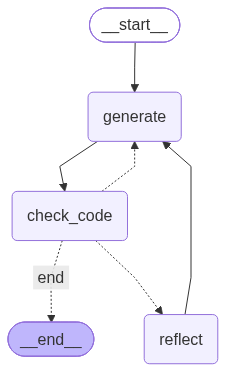

In [54]:
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

In [ ]:
question = "문자열을 Runnable 객체에 직접 전달해 프롬프트 입력을 구성하려면 어떻게 해야 하나요?"

result = app.invoke(
    {
        "question": question,
        "messages": [("user", question)],
        "iterations": 0,
        "error": "no",
        "error_message": "",
    }
)

print(result["generation"])
